# Import Library :

In [ ]:
!pip install optuna nltk

In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize

from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns
import optuna

nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Dataset :

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load CSV
import os
file_path = "../../Dataset/Pre-Processed Dataset/Before_remove@and#/combined_dataset.csv"
if not os.path.exists(file_path):
    file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]


# Train–Val–Test Split

In [ ]:
# ============================================
# PART 2 — Train–Val–Test Split
# ============================================

# Step 1: Pisahkan test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: Dari sisa 80%, ambil 12.5% sebagai validation (~10% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# Load FastText Embedding (dari Google Drive)

In [ ]:
import os
fasttext_path = "../../cc.id.300.vec"
if not os.path.exists(fasttext_path):
    fasttext_path = "/content/drive/MyDrive/DistilBERT-7-Mei/cc.id.300.vec"

def load_fasttext_embeddings(path):
    print("Loading FastText vectors...")
    embeddings = {}
    with open(path, "r", encoding="utf-8", newline="\n", errors="ignore") as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector
    print("FastText Loaded.")
    return embeddings

fasttext = load_fasttext_embeddings(fasttext_path)
embedding_dim = len(next(iter(fasttext.values())))
print("Embedding dimension:", embedding_dim)


Loading FastText vectors...
FastText Loaded.
Embedding dimension: 300


# Tokenizing + Convert Sentence → Vector

In [ ]:
def sentence_to_vector(sentence, ft_dict, dim):
    tokens = word_tokenize(sentence.lower())
    vecs = [ft_dict[t] for t in tokens if t in ft_dict]

    if len(vecs) == 0:
        return np.zeros(dim)

    return np.mean(vecs, axis=0)


# Convert Train/Val/Test → Embedding Matrix

In [ ]:
import nltk
nltk.download('punkt_tab')

X_train_vec = np.array([sentence_to_vector(t, fasttext, embedding_dim) for t in X_train])
X_val_vec   = np.array([sentence_to_vector(t, fasttext, embedding_dim) for t in X_val])
X_test_vec  = np.array([sentence_to_vector(t, fasttext, embedding_dim) for t in X_test])

print("Vector shapes:")
print(X_train_vec.shape, X_val_vec.shape, X_test_vec.shape)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Vector shapes:
(1445, 300) (207, 300) (414, 300)


# OPTUNA

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.svm import SVC
import numpy as np

def objective(trial):

    C = trial.suggest_float("C", 1e-3, 10, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True) if kernel == "rbf" else "scale"

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in kf.split(X_train_vec):
        X_fold_train = X_train_vec[train_idx]
        X_fold_val   = X_train_vec[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val   = y_train.iloc[val_idx]

        model = SVC(
            C=C,
            kernel=kernel,
            gamma=gamma,
            probability=True,
            random_state=42
        )

        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)

        f1 = f1_score(y_fold_val, preds, average="macro")
        f1_scores.append(f1)

    return np.mean(f1_scores)


# Run Optuna

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)
print("Best Val F1:", study.best_value)


[I 2025-11-25 08:29:16,870] A new study created in memory with name: no-name-2bc0ed2f-fa1b-4c12-9d32-2ac19de6eed9
[I 2025-11-25 08:29:22,087] Trial 0 finished with value: 0.8386997981822011 and parameters: {'C': 1.1446511555142391, 'kernel': 'linear'}. Best is trial 0 with value: 0.8386997981822011.
[I 2025-11-25 08:29:31,839] Trial 1 finished with value: 0.35435992637270947 and parameters: {'C': 0.0029566528194343487, 'kernel': 'linear'}. Best is trial 0 with value: 0.8386997981822011.
[I 2025-11-25 08:29:41,790] Trial 2 finished with value: 0.35435992637270947 and parameters: {'C': 0.006667900988366387, 'kernel': 'linear'}. Best is trial 0 with value: 0.8386997981822011.
[I 2025-11-25 08:29:45,823] Trial 3 finished with value: 0.43750953223785805 and parameters: {'C': 0.06728168139554566, 'kernel': 'linear'}. Best is trial 0 with value: 0.8386997981822011.
[I 2025-11-25 08:29:49,851] Trial 4 finished with value: 0.35435992637270947 and parameters: {'C': 0.004164062988035325, 'kernel'

Best Params: {'C': 7.08603364143297, 'kernel': 'rbf', 'gamma': 0.9625733261421018}
Best Val F1: 0.8776398950489671


# Train Final Model dengan Train + Val (FULL TRAINING DATA)

In [ ]:
best_params = study.best_params
gamma = best_params["gamma"] if best_params["kernel"] == "rbf" else "scale"

final_model = SVC(
    C=best_params["C"],
    kernel=best_params["kernel"],
    gamma=gamma,
    probability=True,
    random_state=42
)

# Train menggunakan TRAIN + VAL (digabung)
X_fulltrain = np.concatenate([X_train_vec, X_val_vec])
y_fulltrain = pd.concat([y_train, y_val])

final_model.fit(X_fulltrain, y_fulltrain)


SVC(C=7.08603364143297, gamma=0.9625733261421018, probability=True,
    random_state=42)

# FINAL TEST EVALUATION


Classification Report:
              precision    recall  f1-score   support

    Bullying     0.8379    0.9298    0.8815       228
Non-bullying     0.9006    0.7796    0.8357       186

    accuracy                         0.8623       414
   macro avg     0.8693    0.8547    0.8586       414
weighted avg     0.8661    0.8623    0.8609       414



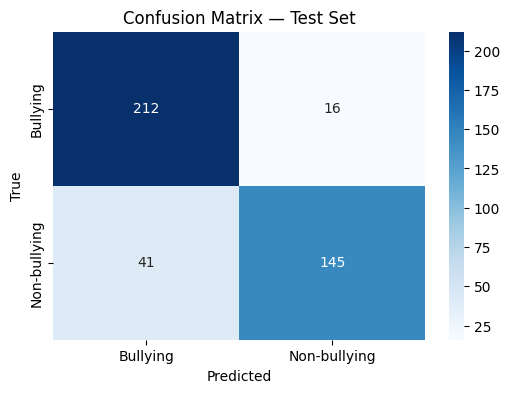

In [ ]:
y_pred = final_model.predict(X_test_vec)
test_f1 = f1_score(y_test, y_pred, average="macro")


label_map = {0: "Bullying", 1: "Non-bullying"}
class_names = [label_map[i] for i in sorted(label_map.keys())]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()


# Save Model Configuration Summary :

In [ ]:
import json
from pprint import pprint

# Ambil best param dari Optuna
best_C = study.best_params["C"]
best_kernel = study.best_params["kernel"]
best_gamma = gamma  # gamma sudah kita set sebelumnya
EMB_DIM = embedding_dim

experiment_config = {
    "tokenizer": "nltk.word_tokenize",
    "embedding": "fasttext",
    "embedding_dim": EMB_DIM,
    "model": "svm",
   "use_kfold": True,
   "kfold_splits": 5,


    "svm_C": best_C,
    "svm_kernel": best_kernel,
    "svm_gamma": best_gamma,

    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test)
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))

print("\nFinal Test Macro F1:", f"{test_f1:.4f}")



Experiment Configuration:
{'embedding': 'fasttext',
 'embedding_dim': 300,
 'kfold_splits': 5,
 'model': 'svm',
 'svm_C': 7.08603364143297,
 'svm_gamma': 0.9625733261421018,
 'svm_kernel': 'rbf',
 'test_size': 414,
 'tokenizer': 'nltk.word_tokenize',
 'train_size': 1445,
 'use_kfold': True,
 'val_size': 207}

JSON Format:
{
    "tokenizer": "nltk.word_tokenize",
    "embedding": "fasttext",
    "embedding_dim": 300,
    "model": "svm",
    "use_kfold": true,
    "kfold_splits": 5,
    "svm_C": 7.08603364143297,
    "svm_kernel": "rbf",
    "svm_gamma": 0.9625733261421018,
    "train_size": 1445,
    "val_size": 207,
    "test_size": 414
}

Final Test Macro F1: 0.8586
